## IMPORT LIBRARY AND PATH CONFIGURATION

In [9]:
import sys
from pathlib import Path
import numpy as np
from scipy.io import loadmat
from scipy.interpolate import interp1d

# Add python/ to PYTHONPATH (project root for Python code)
PROJECT_ROOT = Path(".").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Python project root:", PROJECT_ROOT)


Python project root: C:\UNIFI\LM Bio UniFi\Thesis\KNEE-JOINT-KINEMATICS-SIMULATION\Python


## IMPORT MODULES

In [10]:
from scripts.data_extraction_from_motive import Read_dataRB
from scripts.VirtualPoints_coordinate_extraction import export_virtual_points
from scripts.MotiveWorld_coordinate import Global_points
from scripts.UnityWorld_coordinate import Mesh_to_World_Pipeline
from scripts.Pipeline_Validation  import load_mesh_to_world,grood_suntay_pipeline, RMS_error

### **READ RAW DATA FROM MOTIVE**

In [11]:
bodies = {
    "Tibia": "tibiaTransform.csv",
    "Femur": "femurTransform.csv",
     "Patella": "PatellaTransform.csv",
}

Read_dataRB(
    src_csv="../data/csv_files/dataRigidBody.csv",
    output_dir="../data/csv_files",
    bodies=bodies
)


File created: ../data/csv_files/tibiaTransform.csv
File created: ../data/csv_files/femurTransform.csv
File created: ../data/csv_files/PatellaTransform.csv


### **LANDMARK PREPROCESSING**

In [12]:
# MESH LOCAL POINTS (BLENDER → MOTIVE)
Rot_B2M = np.diag([-1.0, 1.0, -1.0])
anatomy = {
    "tibia": {
        # Mechanical axis points
        "prox": Rot_B2M @ np.array([0.001114,  0.142, -0.001801], dtype=float),
        "dist": Rot_B2M @ np.array([ 0.002285, -0.18949,   0.004076], dtype=float),

        # Surface / landmark points (used for Kabsch & validation)
        "AMT": Rot_B2M @ np.array([-0.02177, -0.216489,  0.019932], dtype=float),
        "ALT": Rot_B2M @ np.array([0.008161, -0.207676,  -0.00993],       dtype=float),
        "LT":  Rot_B2M @ np.array([ 0.030979,  0.169514, -0.022989], dtype=float),
        "MT":  Rot_B2M @ np.array([-0.037745,  0.16651,  0.005438], dtype=float),
    },

    "femur": {
        # Mechanical axis points
        "head": Rot_B2M @ np.array([-0.017593,  0.225445,  0.028621], dtype=float),
        "dist": Rot_B2M @ np.array([-0.010087, -0.164445, -0.004805 ], dtype=float),

        # Condyles / landmarks
        "LF":   Rot_B2M @ np.array([ 0.022548, -0.207434, -0.032849], dtype=float),
        "MF":   Rot_B2M @ np.array([-0.054633, -0.204439, -0.003766], dtype=float),
    },

    "patella": {
        "PP": Rot_B2M @ np.array([ 0.00104400,  -0.02765099,  0.005901016], dtype=float),
        "MP": Rot_B2M @ np.array([-0.01865400,  -0.00665200, -0.008743007], dtype=float),
        "LP": Rot_B2M @ np.array([ 0.01838301,  -0.01326200,  0.01198900 ], dtype=float),
    }
}

### **LOAD VP COORDIANTE ACQUIRED IN MATLAB**

In [13]:
virtual_points = {
    "Femur": {
        "points": ["femurAFlocal", "femurLFlocal", "femurMFlocal"],
        "output": "femurVP.csv",
    },
    "Tibia": {
        "points": ["tibiaALTlocal", "tibiaAMTlocal", "tibiaLTlocal", "tibiaMTlocal"],
        "output": "tibiaVP.csv",
    },
    "Patella": {
        "points": ["patellaDPlocal", "patellaMPlocal", "patellaLPlocal", "patellaPPlocal"],
        "output": "patellaVP.csv"
    }
    }

export_virtual_points(mat_file="../data/matlab/virtualPoint_DEMO.mat",
                      output_dir="../data/csv_files",
                      virtual_points=virtual_points )

File created: ..\data\csv_files\femurVP.csv
File created: ..\data\csv_files\tibiaVP.csv
File created: ..\data\csv_files\patellaVP.csv


c:\UNIFI\LM Bio UniFi\Thesis\KNEE-JOINT-KINEMATICS-SIMULATION\Python\venv_knee_project\Lib\site-packages\scipy\io\matlab\_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


### **COMPUTATION OF MOTIVE GLOBAL COORDINATES**

In [14]:
Global_points(tibia_transform_csv="../data/csv_files/tibiaTransform.csv",
              femur_transform_csv="../data/csv_files/femurTransform.csv",
             patella_transform_csv="../data/csv_files/patellaTransform.csv",
              femur_vp_csv="../data/csv_files/femurVP.csv",
              tibia_vp_csv="../data/csv_files/tibiaVP.csv",
              patella_vp_csv="../data/csv_files/patellaVP.csv",
              output_dir="../data/csv_files",
              output_RT_dir="../data/Rigid_Transformation")

### **COMPUTATION OF R,T MESH LOCAL REFERENCE FRAME --> MOTIVE GLOBAL WORLD**

In [15]:
Mesh_to_World_Pipeline(
              tibia_vp_csv="../data/csv_files/tibiaVP.csv",
              femur_vp_csv="../data/csv_files/femurVP.csv",
              patella_vp_csv="../data/csv_files/patellaVP.csv",
              tibia_transform_csv="../data/csv_files/tibiaTransform.csv",
              femur_transform_csv="../data/csv_files/femurTransform.csv",
              patella_transform_csv="../data/csv_files/patellaTransform.csv",
              output_dir="../data/csv_files",
              output_RT_dir="../data/Rigid_Transformation",
              anatomy=anatomy)

Mesh → World pipeline completed successfully.


### **METRICS FOR VALIDARION AND GRAPHICS**

c:\UNIFI\LM Bio UniFi\Thesis\KNEE-JOINT-KINEMATICS-SIMULATION\Python\venv_knee_project\Lib\site-packages\scipy\io\matlab\_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


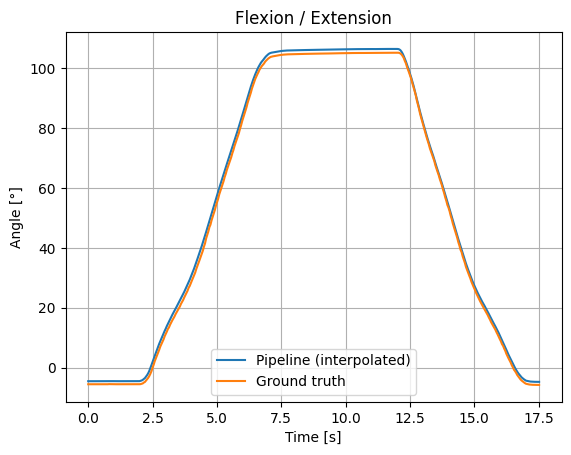


FE
 min   : -4.74°
 max   : 106.40°
 delta : 111.15°


Mean offset VV [deg]: 1.33
Std VV error  [deg]: 0.46


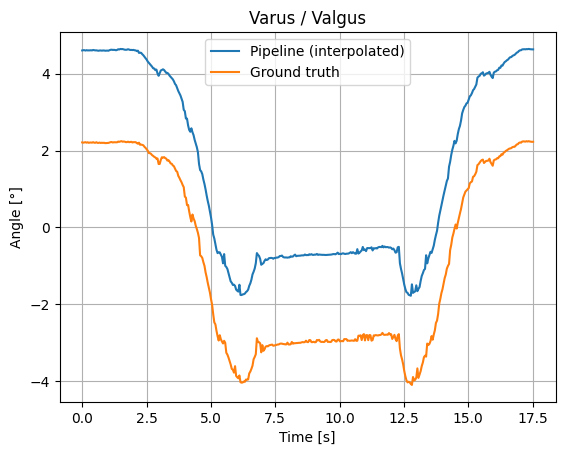


VV
 min   : -1.78°
 max   : 4.66°
 delta : 6.44°


Mean offset VV [deg]: 2.29
Std VV error  [deg]: 0.09


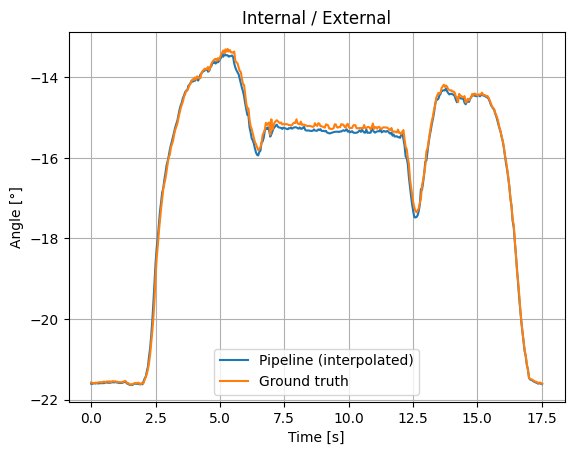


IE
 min   : -21.64°
 max   : -13.40°
 delta : 8.24°


Mean offset VV [deg]: -0.06
Std VV error  [deg]: 0.10

RMS ERROR VALUE FOR EACH BONE MODEL (mm) 

Tibia : 3.12
Femur: 3.76
Patella: 2.28


In [16]:
import matplotlib.pyplot as plt

R_tibia,   T_tibia   = load_mesh_to_world("../data/Rigid_Transformation/mesh_to_world_tibia.npz")
R_femur,   T_femur   = load_mesh_to_world("../data/Rigid_Transformation/mesh_to_world_femur.npz")
R_patella, T_patella = load_mesh_to_world("../data/Rigid_Transformation/mesh_to_world_patella.npz")

# Compute Grood & Suntay  angles
FE, VV, IE = grood_suntay_pipeline(
    R_femur, T_femur,
    R_tibia, T_tibia,
    anatomy,
    side="LEFT"
)


matlab=loadmat("../data/matlab/Native1_output")
GT_FE=matlab["calcFE"].squeeze()
GT_VV=matlab["calcVV"].squeeze()
GT_IE=matlab["calcIE"].squeeze()

# Interpolation for plotting graphs with time on the x‑axis
fs_trial = 100.0                 # Hz (pipeline)
fs_GT = len(GT_FE) / 17.56       # ground truth

t_trial = np.arange(len(FE)) / fs_trial
t_GT = np.arange(len(GT_FE)) / fs_GT

interp = lambda sig: interp1d(
    t_trial, sig,
    kind="linear",
    fill_value="extrapolate"
)(t_GT)

FE_i = interp(FE)
VV_i = interp(VV)
IE_i = interp(IE)

def plot_comparison(t, sig_i, sig_GT, title):
    plt.figure()
    plt.plot(t, sig_i, label="Pipeline (interpolated)")
    plt.plot(t, sig_GT, label="Ground truth")
    plt.title(title)
    plt.xlabel("Time [s]")
    plt.ylabel("Angle [°]")
    plt.grid(True)
    plt.legend()
    plt.show()

    
def print_stats(name, sig):
    print(f"\n{name}")
    print(f" min   : {sig.min():.2f}°")
    print(f" max   : {sig.max():.2f}°")
    print(f" delta : {(sig.max() - sig.min()):.2f}°\n")

plot_comparison(t_GT, FE_i, GT_FE, "Flexion / Extension")
print_stats("FE", FE)
FE_err = FE_i - GT_FE
print(f"\nMean offset VV [deg]: {np.mean(FE_err):.2f}")
print(f"Std VV error  [deg]: {np.std(FE_err):.2f}")

plot_comparison(t_GT, VV_i, GT_VV, "Varus / Valgus")
print_stats("VV", VV)
vv_err = VV_i - GT_VV
print(f"\nMean offset VV [deg]: {np.mean(vv_err):.2f}")
print(f"Std VV error  [deg]: {np.std(vv_err):.2f}")

plot_comparison(t_GT, IE_i, GT_IE, "Internal / External")
print_stats("IE", IE)
IE_err = IE_i - GT_IE
print(f"\nMean offset VV [deg]: {np.mean(IE_err):.2f}")
print(f"Std VV error  [deg]: {np.std(IE_err):.2f}\n")



# RMS ERROR
err_tibia, err_femur, err_patella = RMS_error(
    R_tibia, T_tibia,
    R_femur, T_femur,
    R_patella, T_patella,
    anatomy=anatomy,
    tibia_global_csv="../data/csv_files/tibiaGlobalPoints.csv",
    femur_global_csv="../data/csv_files/femurGlobalPoints.csv",
    patella_global_csv="../data/csv_files/patellaGlobalPoints.csv",
    
)

print("\033[1mRMS ERROR VALUE FOR EACH BONE MODEL (mm)\033[0m ")
print(f"\nTibia : {err_tibia.mean() * 1000:.2f}")
print(f"Femur: {err_femur.mean() * 1000:.2f}")
print(f"Patella: {err_patella.mean() * 1000:.2f}")
